In [259]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sys.path.append(os.path.abspath(".."))

from config import RFM_DATA_PATH

In [260]:
df=pd.read_csv(RFM_DATA_PATH)
df.head(
)

,CustomerID,Recency,Frequency,Monetary,R,F,M,rfm_score,customer_segmentation
0,12346,326,1,77183.60,1,1,5,115,Standard Customer
1,12347,2,7,4310.00,5,5,5,555,VIP
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,Standard Customer
4,12350,310,1,334.40,1,1,2,112,Hibernating


In [261]:
df_new = np.log1p(df[["Recency","Frequency","Monetary"]])
df_new.rename(columns={"Recency":"log_recency","Frequency":"log_frequency","Monetary":"log_monetary"},inplace=True)
df_new.head()

,log_recency,log_frequency,log_monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [262]:
ss=StandardScaler()
scaled_data = ss.fit_transform(df_new)

In [263]:
inertia=[]
for cnt in range(1,11):
    kmeans = KMeans(n_clusters=cnt,random_state=42).fit(scaled_data)
    inertia.append(kmeans.inertia_)

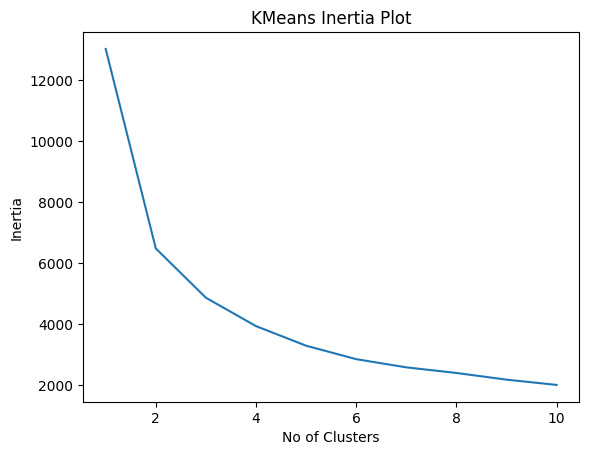

In [264]:
sns.lineplot(y=inertia,x=range(1,11)).set_title("KMeans Inertia Plot")
plt.xlabel("No of Clusters")
plt.ylabel("Inertia")
plt.show()

In [265]:
kmeans_model = KMeans(n_clusters=4,random_state=42).fit(scaled_data)
df["ml_cluster"] = kmeans_model.labels_

In [266]:
df["ml_cluster"].value_counts()

ml_cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64

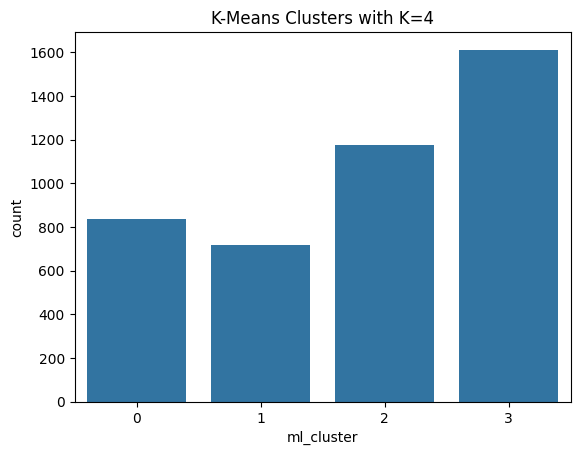

In [267]:
sns.countplot(data=df,x="ml_cluster").set_title("K-Means Clusters with K=4")
plt.show()

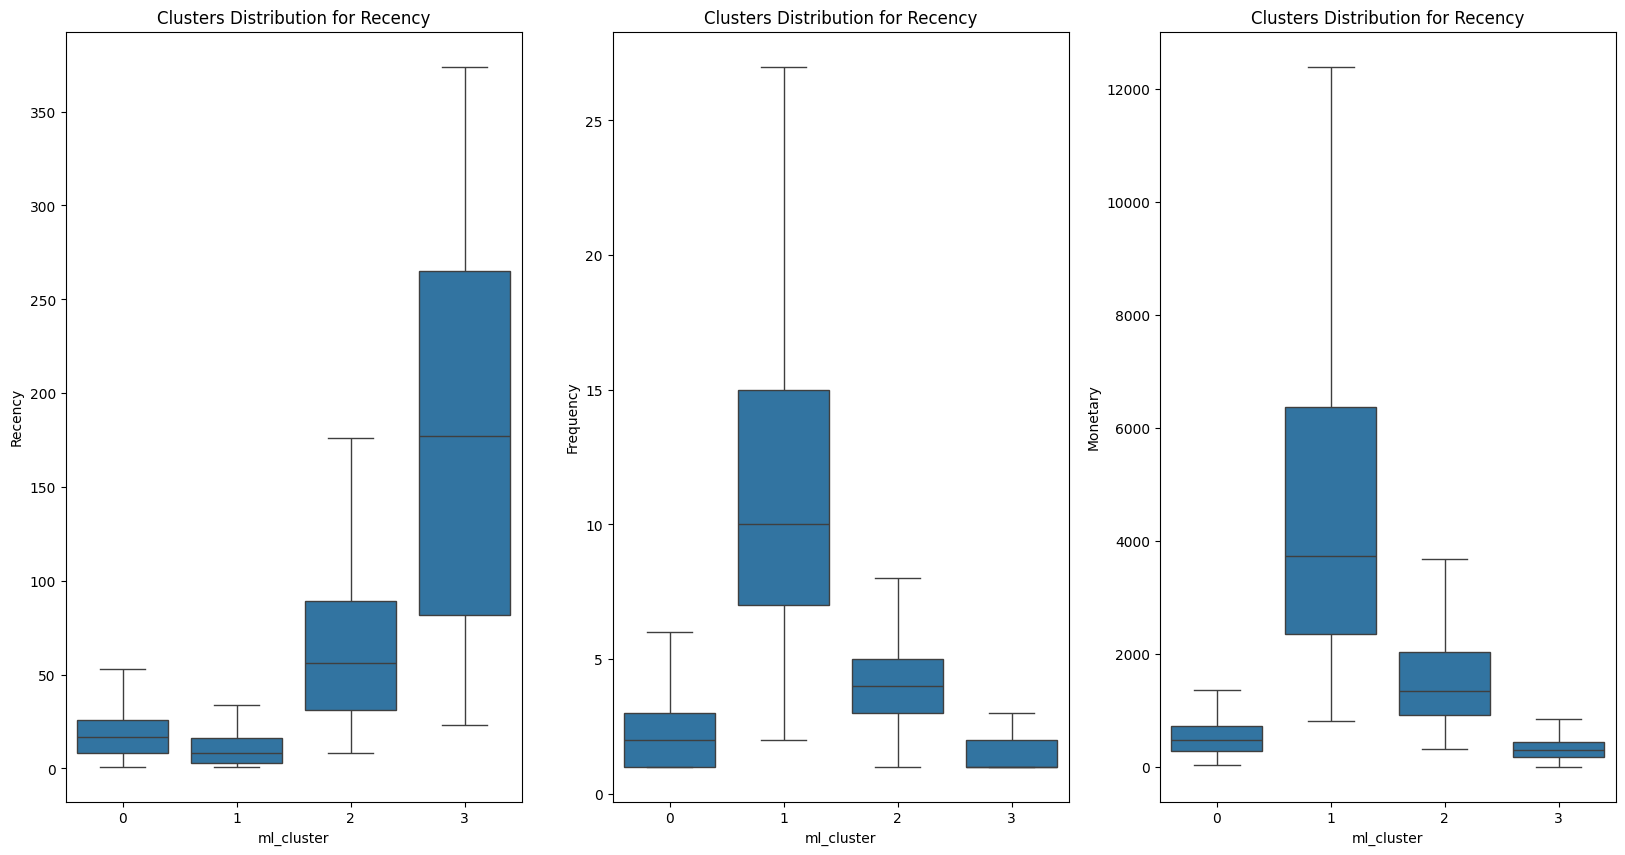

In [268]:
fig,axes = plt.subplots(1,3,figsize=(20,10))

sns.boxplot(data=df,y="Recency",x="ml_cluster",ax=axes[0],showfliers=False).set_title("Clusters Distribution for Recency")
sns.boxplot(data=df,y="Frequency",x="ml_cluster",ax=axes[1],showfliers=False).set_title("Clusters Distribution for Recency")
sns.boxplot(data=df,y="Monetary",x="ml_cluster",ax=axes[2],showfliers=False).set_title("Clusters Distribution for Recency")

plt.show()

In [269]:
pd.pivot_table(df,values=["Recency","Frequency","Monetary"],index="ml_cluster",aggfunc="mean").round(2)

,Frequency,Monetary,Recency
ml_cluster,,,
0,2.15,551.82,18.12
1,13.71,8074.27,12.13
2,4.08,1802.83,71.08
3,1.32,343.45,182.50


In [270]:
df["ml_cluster"] = df["ml_cluster"].replace({0:"New Buyers",1:"Elite Buyers",2:"At Risk Buyers",3:"Hibernating Buyers"})
df.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,rfm_score,customer_segmentation,ml_cluster
0,12346,326,1,77183.60,1,1,5,115,Standard Customer,At Risk Buyers
1,12347,2,7,4310.00,5,5,5,555,VIP,Elite Buyers
2,12348,75,4,1797.24,2,4,4,244,At Risk,At Risk Buyers
3,12349,19,1,1757.55,4,1,4,414,Standard Customer,New Buyers
4,12350,310,1,334.40,1,1,2,112,Hibernating,Hibernating Buyers


In [271]:
group_df = df.groupby("ml_cluster")[["Recency","Frequency","Monetary"]].mean()
group_df = np.log1p(group_df).reset_index()
melt_df = pd.melt(group_df,id_vars=["ml_cluster"],value_vars=["Recency","Frequency","Monetary"])
melt_df = melt_df.rename(columns={"variable":"metric"})
melt_df

,ml_cluster,metric,value
0,At Risk Buyers,Recency,4.277838
1,Elite Buyers,Recency,2.574998
2,Hibernating Buyers,Recency,5.212198
3,New Buyers,Recency,2.950957
4,At Risk Buyers,Frequency,1.626009
5,Elite Buyers,Frequency,2.688778
6,Hibernating Buyers,Frequency,0.840808
7,New Buyers,Frequency,1.146814
8,At Risk Buyers,Monetary,7.497667
9,Elite Buyers,Monetary,8.996561


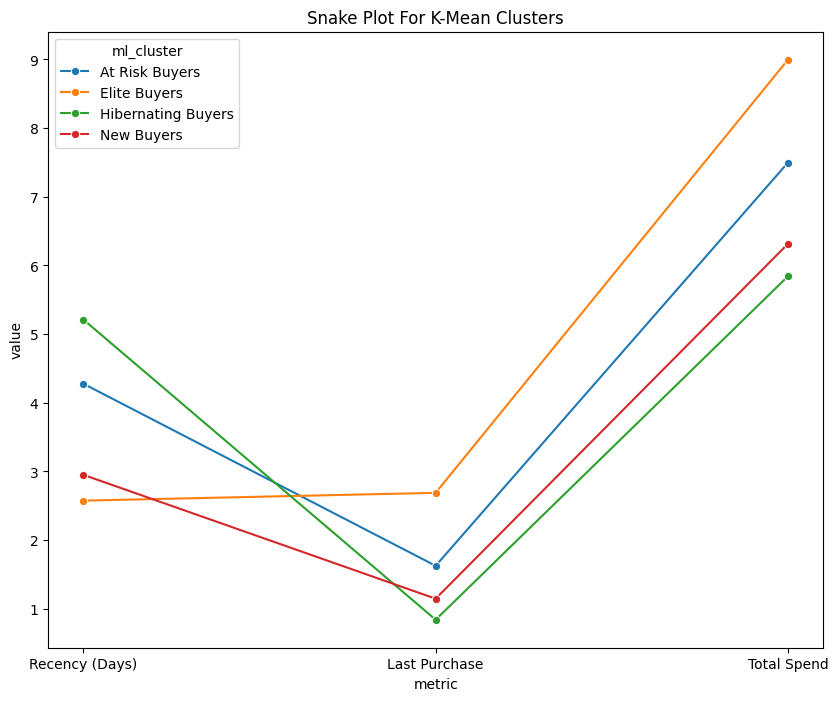

In [297]:
plt.figure(figsize=(10,8))
sns.lineplot(melt_df,x="metric",y="value",hue="ml_cluster",marker="o").set_title("Snake Plot For K-Mean Clusters")
plt.xticks(ticks=[0,1,2],labels=["Recency (Days)","Last Purchase","Total Spend"])
plt.show()